In [1]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
import operator

c:\Users\pumas\AppData\Local\Programs\Python\Python313\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [3]:
class State(TypedDict):
    topic:str
    essay:str
    language_feedback:str
    thought_feedback:str
    depth_feedback:str
    individual_score: Annotated[list[int],operator.add]
    feedback_summary:str
    average_score:float

In [4]:
class Eval_Schema(BaseModel):
    essay_feedback: str = Field(description="Feedback for the essay written by the user")
    score: int = Field(description="Score for the essay based on the evaluation between 0-10",ge=0,le=10)

In [5]:
model = ChatGroq(model="openai/gpt-oss-20b")
model_with_structure = model.with_structured_output(Eval_Schema)

In [6]:
def language_evaluation(old_state:State) -> State:
    prompt=f"""You are a professional editor, reviewing essay on the basis of language used by the user. You will look and evaluate the overall language used by the user throughtout the essay. After evaluating the language properly you will return the language feedback and a score between 0-10. \n"""
    prompt+=f"Topic for the essay was {old_state['topic']}"
    prompt+=f"Essay written by the user in which you will evaluate the language used:\n{old_state["essay"]}"

    response = model_with_structure.invoke(prompt)

    return {"language_feedback":response.essay_feedback,"individual_score":[response.score]}


def thought_evaluation(old_state:State) -> State:
    prompt=f"""You are a professional editor, reviewing essay on the basis of thought shown by the user. You will look and evaluate the overall thought of the user throughtout the essay. After evaluating the thought properly you will return the thought feedback and a score between 0-10.\n """
    prompt+=f"Topic for the essay was {old_state['topic']}"
    prompt+=f"Essay written by the user in which you will evaluate the thought used:\n{old_state["essay"]}"

    response = model_with_structure.invoke(prompt)

    return {"thought_feedback":response.essay_feedback,"individual_score":[response.score]}


def depth_evaluation(old_state:State) -> State:
    prompt=f"""You are a professional editor, reviewing essay on the basis of depth used by the user. You will look and evaluate the overall depth used by the user throughtout the essay. After evaluating the depth properly you will return the depth feedback and a score between 0-10.\n """
    prompt+=f"Topic for the essay was {old_state['topic']}"
    prompt+=f"Essay written by the user in which you will evaluate the depth used:\n{old_state["essay"]}"

    response = model_with_structure.invoke(prompt)

    return {"depth_feedback":response.essay_feedback,"individual_score":[response.score]}


def final_evalution(old_state:State) -> State:
    prompt= """You are an expert evaluator which evaluates the essay written by a user based on language_feedback,  thought_evaluation and depth_evaluation which is done by other evaluators. Your job is to summarize the findings of the other evaluators and give a final feedback\n"""
    prompt+=f"Topic for the essay was {old_state['topic']}\n"
    prompt+=f"""Essay: {old_state['essay']}\n
            language_evaluation: {old_state['language_feedback']}\n
            thought_evaluation: {old_state['thought_feedback']}\n
            depth_evaluation: {old_state['depth_feedback']}\n
            """
    prompt+="Give final feedback summary based on the shared feedbacks."

    response = model.invoke(prompt)
    avg_score = round(sum(old_state['individual_score']) / len(old_state['individual_score']),2)

    return {
            "feedback_summary":response.content,
            'average_score':avg_score
            }

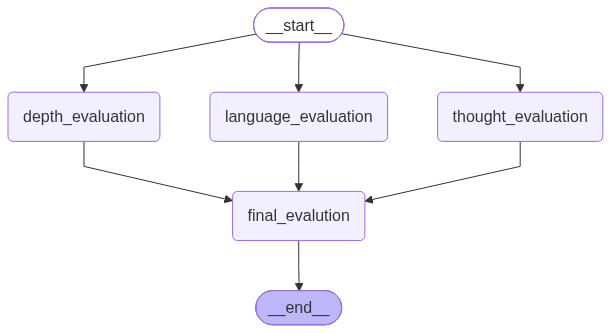

In [7]:
graph = StateGraph(State)
graph.add_node("language_evaluation",language_evaluation)
graph.add_node("thought_evaluation",thought_evaluation)
graph.add_node("depth_evaluation",depth_evaluation)
graph.add_node("final_evalution",final_evalution)


graph.add_edge(START,"language_evaluation")
graph.add_edge(START,"thought_evaluation")
graph.add_edge(START,"depth_evaluation")
graph.add_edge("language_evaluation","final_evalution")
graph.add_edge("thought_evaluation","final_evalution")
graph.add_edge("depth_evaluation","final_evalution")
graph.add_edge("final_evalution",END)

workflow = graph.compile()
workflow

In [8]:
input_data = {
    "topic": "The Impact of Technology on Modern Education",
    "essay": """
Technology has transformed almost every aspect of modern life, and education is no exception. 
From online classrooms and digital textbooks to artificial intelligence and educational applications, 
technology has changed the way students learn and teachers teach. When used effectively, technology 
can make education more accessible, interactive, and personalized.

One of the greatest advantages of technology in education is accessibility. In the past, students 
often depended on physical books, libraries, and classroom instruction. Today, learners can access 
a vast amount of information through the internet from almost anywhere. Online courses, recorded 
lectures, and digital resources allow students to continue learning even when they cannot attend a 
traditional classroom. This has been particularly valuable for students living in remote areas or 
those who need flexible learning schedules.

Technology also makes learning more engaging. Interactive simulations, educational videos, virtual 
laboratories, and learning applications can explain difficult concepts in ways that traditional 
textbooks may not. For example, a student learning about the solar system can explore a virtual 
model of planets instead of simply reading about them. Such experiences can increase curiosity and 
help students understand and remember complex ideas.

Another important benefit is personalized learning. Every student learns at a different pace and 
has different strengths and weaknesses. Digital learning platforms can provide exercises according 
to a student's ability and offer immediate feedback. Artificial intelligence can further support 
this process by identifying areas where a student is struggling and suggesting suitable learning 
materials. As a result, students can receive more individualized support rather than following 
exactly the same learning path.

However, technology also creates challenges. Excessive dependence on digital devices can reduce 
face-to-face interaction and may cause distraction. Not every student has reliable internet access 
or modern devices, which can create an educational gap between different groups of learners. 
Furthermore, the enormous amount of information available online makes it important for students 
to develop critical-thinking and digital-literacy skills so that they can distinguish reliable 
sources from misinformation.

Therefore, technology should not be viewed as a replacement for teachers but as a powerful tool 
that can support them. Teachers provide guidance, motivation, emotional support, and human 
connection—qualities that technology alone cannot fully replace. The best educational system is 
one that combines the strengths of technology with the experience and understanding of teachers.

In conclusion, technology has the potential to greatly improve modern education by increasing 
accessibility, engagement, and personalization. At the same time, its challenges must be addressed 
carefully. If technology is used responsibly and combined with effective teaching, it can help 
create an education system that is more inclusive, flexible, and capable of preparing students 
for the demands of the future.
"""
}

In [9]:
response = workflow.invoke(input_data)
response

{'topic': 'The Impact of Technology on Modern Education',
 'essay': "\nTechnology has transformed almost every aspect of modern life, and education is no exception. \nFrom online classrooms and digital textbooks to artificial intelligence and educational applications, \ntechnology has changed the way students learn and teachers teach. When used effectively, technology \ncan make education more accessible, interactive, and personalized.\n\nOne of the greatest advantages of technology in education is accessibility. In the past, students \noften depended on physical books, libraries, and classroom instruction. Today, learners can access \na vast amount of information through the internet from almost anywhere. Online courses, recorded \nlectures, and digital resources allow students to continue learning even when they cannot attend a \ntraditional classroom. This has been particularly valuable for students living in remote areas or \nthose who need flexible learning schedules.\n\nTechnolog